> # ⚠️ Correction — the headline result in this notebook is superseded
>
> This notebook reproduces the **original** study, which used a **row-level** cross-validation split.
> Prof. Taniike (JAIST) pointed out that the dataset contains many measurements of the same catalyst,
> so a row-level split places the same catalyst in both training and test folds.
>
> **Under catalyst-grouped cross-validation the reported ~10% improvement does not survive**
> (baseline 2.943 vs. prior-feature method 2.995). The gain was catalyst-identity leakage: Stage 1
> was trained on literature data *together with the lab training rows*, so the prior feature partly
> carried each test catalyst's own measured yields.
>
> **Sections 1–10 below are retained as an honest record of the original analysis**, and their
> numbers are correct *as row-level results* — they are simply not evidence of successful transfer.
> The corrected evaluation is in **Section 11** at the end of this notebook.
>
> | | Row-level (below) | Catalyst-grouped (correct) |
> |---|---|---|
> | Baseline RMSE | 2.118 | 2.943 |
> | Prior-feature method | 1.912 (−9.7%) | 2.995 (**+1.8%**) |
>
> Corrected protocol and experiments: `ocm_eval.py`, `taniike_validation.py`, `phase3_lit_prior.py`,
> `phase4_family_diagnosis.py`, `phase5_target_audit.py`, `phase6_our_experiments.py`,
> `phase6_candidates.py`. Full write-up: `ocm_worknote_taniike.md` (v2).


# OCM Methodology — From Baseline to Prior Feature Transfer

**Clean, self-contained methodology notebook for external sharing.** It covers only the five methods we evaluated — baseline, naive merge, DRST, KMM, and two-stage Prior Feature Transfer (PFT) — plus a repeatability and held-out check that shows the results are real, not accidental. Every number and figure below is a stored output of running this notebook top to bottom; nothing is hand-entered.

*(This is separate from `ocm_walkthrough.ipynb`, which is the internal presentation notebook with the slide narrative and a reviewer Q&A appendix — that one is not meant for external sharing.)*

**Datasets.** Lab data = 89,074 in-house experiments (2025, impregnation). Literature data = 3,852 published experiments (1982–2019). Target = C2 yield `Y(C2), %`. Every method is scored by 5-fold cross-validation whose validation fold is **always lab data only** — literature data may only help on the training side, so the number always answers "how well do we predict our own experiments."

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata, ttest_rel, wilcoxon
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb, xgboost as xgb
np.random.seed(42)

## 1. Data

Load the combined CSV, split into **lab data** (year 2025) and **literature data** (year ≤ 2019), build the
67-feature matrix (temperature, preparation code, 63 element loadings), and standardise features on the
**lab data** ruler (fit on lab, apply to literature).

In [2]:
DATA_PATH = 'OCM_lab_data_and_literature_datal.csv'
TARGET = 'Y(C2), %'
df = pd.read_csv(DATA_PATH)
df_lab = df[df['year'] == 2025].reset_index(drop=True)      # lab data
df_lit = df[df['year'] <= 2019].reset_index(drop=True)      # literature data

ELEM_COLS = [c for c in df.columns if c not in ['Preparation', 'Temperature_C', TARGET, 'year']]
le = LabelEncoder().fit(df['Preparation'])
df_lab['prep_enc'] = le.transform(df_lab['Preparation'])
df_lit['prep_enc'] = le.transform(df_lit['Preparation'])
FEATURES = ['Temperature_C', 'prep_enc'] + ELEM_COLS

X_lab = df_lab[FEATURES].values.astype(float); y_lab = df_lab[TARGET].values
X_lit = df_lit[FEATURES].values.astype(float); y_lit = df_lit[TARGET].values

scaler = StandardScaler()
X_lab_sc = scaler.fit_transform(X_lab)     # fit on lab data
X_lit_sc = scaler.transform(X_lit)         # apply to literature data

print(f"lab data       : {X_lab.shape[0]:,} rows   mean Y(C2) = {y_lab.mean():.2f}%")
print(f"literature data: {X_lit.shape[0]:,} rows   mean Y(C2) = {y_lit.mean():.2f}%")
print(f"features       : {len(FEATURES)}   |   label shift (lit - lab) = {y_lit.mean()-y_lab.mean():+.2f} pp")

lab data       : 89,074 rows   mean Y(C2) = 5.25%
literature data: 3,852 rows   mean Y(C2) = 8.67%
features       : 67   |   label shift (lit - lab) = +3.42 pp


### The two distribution shifts (report Figures 1-2)

Before evaluating any method, we visualise the two differences between the datasets that make this a domain-adaptation problem: the **label shift** (literature yields sit ~3.4 pp above the lab) and the **covariate shift** (the two datasets emphasise different elements). These two cells produce report figures `fig_mean_shift.png` and `fig_element_usage.png`.

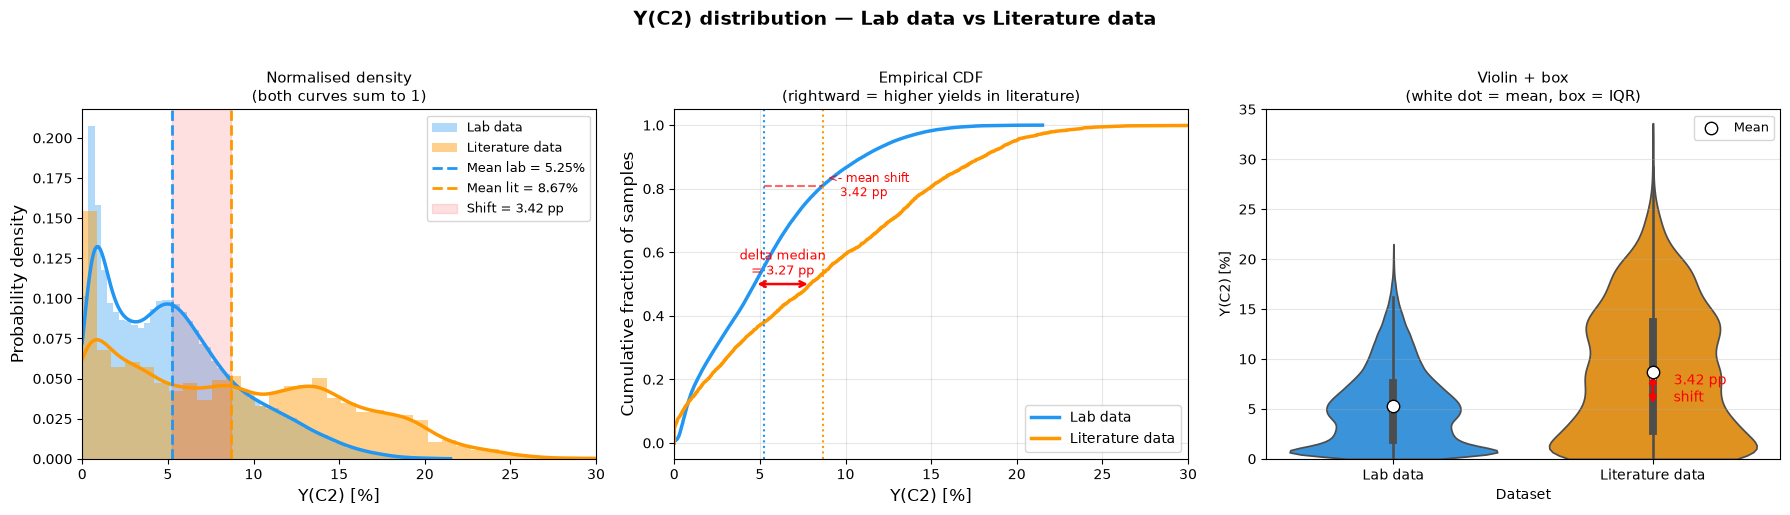

Lab mean 5.245%  |  Literature mean 8.670%  |  shift 3.425 pp  -> fig_mean_shift.png


In [3]:
# ── Report Figure 1 — label shift (three complementary views) ────────────────
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Y(C2) distribution — Lab data vs Literature data", fontsize=14, fontweight='bold', y=1.02)
BLUE = '#2196F3'; ORANGE = '#FF9800'
mean_lab = y_lab.mean(); mean_lit = y_lit.mean(); shift = mean_lit - mean_lab

# Panel 1: normalised density (hist + KDE)
ax = axes[0]
ax.hist(y_lab, bins=60, density=True, alpha=0.35, color=BLUE,   label='Lab data')
ax.hist(y_lit, bins=40, density=True, alpha=0.45, color=ORANGE, label='Literature data')
for y, color in [(y_lab, BLUE), (y_lit, ORANGE)]:
    kde = gaussian_kde(y, bw_method=0.15); xs = np.linspace(0, y.max(), 400)
    ax.plot(xs, kde(xs), color=color, lw=2.5)
ax.axvline(mean_lab, color=BLUE,   lw=2, ls='--', label=f'Mean lab = {mean_lab:.2f}%')
ax.axvline(mean_lit, color=ORANGE, lw=2, ls='--', label=f'Mean lit = {mean_lit:.2f}%')
ax.axvspan(mean_lab, mean_lit, alpha=0.12, color='red', label=f'Shift = {shift:.2f} pp')
ax.set_xlabel('Y(C2) [%]', fontsize=12); ax.set_ylabel('Probability density', fontsize=12)
ax.set_title('Normalised density\n(both curves sum to 1)', fontsize=11)
ax.set_xlim(0, 30); ax.legend(fontsize=9)

# Panel 2: empirical CDF
ax = axes[1]
for y, color, label in [(y_lab, BLUE, 'Lab data'), (y_lit, ORANGE, 'Literature data')]:
    sy = np.sort(y); cdf = np.arange(1, len(y) + 1) / len(y)
    ax.plot(sy, cdf, color=color, lw=2.5, label=label)
p50_lab = np.percentile(y_lab, 50); p50_lit = np.percentile(y_lit, 50)
ax.annotate('', xy=(p50_lit, 0.50), xytext=(p50_lab, 0.50), arrowprops=dict(arrowstyle='<->', color='red', lw=1.8))
ax.text((p50_lab + p50_lit) / 2, 0.53, f'delta median\n= {p50_lit - p50_lab:.2f} pp', ha='center', fontsize=9, color='red')
frac = (y_lab < mean_lit).mean()
ax.plot([mean_lab, mean_lit], [frac, frac], 'r--', lw=1.5, alpha=0.6)
ax.text(mean_lit + 0.3, frac, f'<- mean shift\n   {shift:.2f} pp', fontsize=8.5, color='red', va='center')
ax.axvline(mean_lab, color=BLUE, lw=1.5, ls=':'); ax.axvline(mean_lit, color=ORANGE, lw=1.5, ls=':')
ax.set_xlabel('Y(C2) [%]', fontsize=12); ax.set_ylabel('Cumulative fraction of samples', fontsize=12)
ax.set_title('Empirical CDF\n(rightward = higher yields in literature)', fontsize=11)
ax.set_xlim(0, 30); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Panel 3: violin + box
ax = axes[2]
plot_df = pd.DataFrame({'Y(C2) [%]': np.concatenate([y_lab, y_lit]),
    'Dataset': ['Lab data'] * len(y_lab) + ['Literature data'] * len(y_lit)})
sns.violinplot(data=plot_df, x='Dataset', y='Y(C2) [%]',
               palette={'Lab data': BLUE, 'Literature data': ORANGE}, inner='box', cut=0, ax=ax)
ax.scatter(['Lab data', 'Literature data'], [mean_lab, mean_lit], color='white', edgecolor='black', s=80, zorder=5, label='Mean')
ax.annotate('', xy=(1, mean_lit), xytext=(1, mean_lab), arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(1.08, (mean_lab + mean_lit) / 2, f'{shift:.2f} pp\nshift', color='red', fontsize=10, va='center')
ax.set_title('Violin + box\n(white dot = mean, box = IQR)', fontsize=11)
ax.legend(fontsize=9); ax.set_ylim(0, 35); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.savefig('fig_mean_shift.png', bbox_inches='tight', dpi=130); plt.show()
print(f"Lab mean {mean_lab:.3f}%  |  Literature mean {mean_lit:.3f}%  |  shift {shift:.3f} pp  -> fig_mean_shift.png")

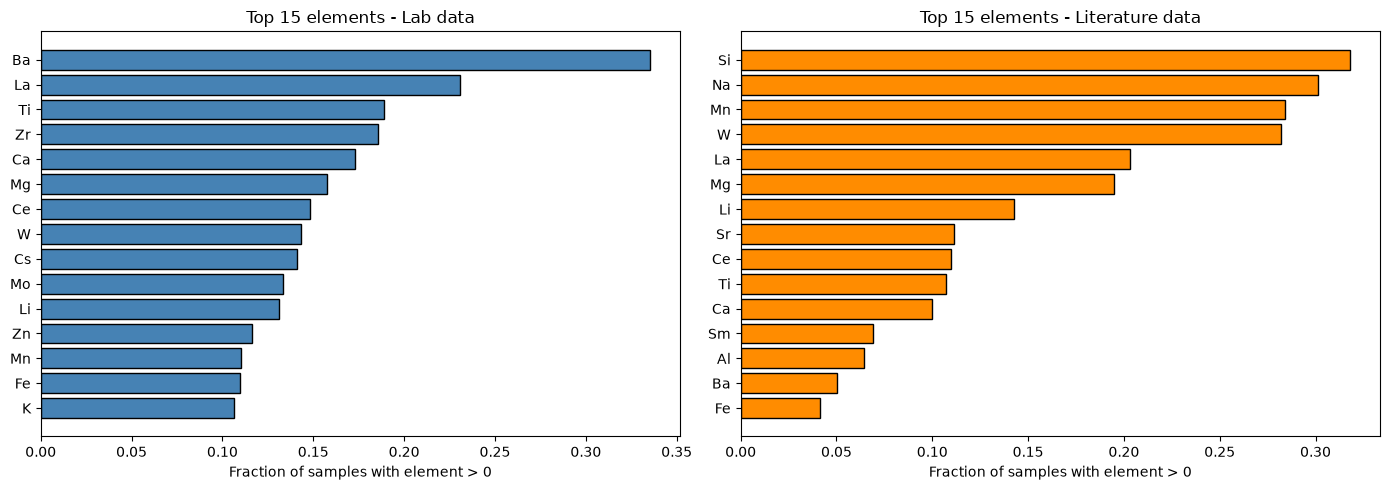

-> fig_element_usage.png


In [4]:
# ── Report Figure 2 — covariate shift (element usage differs) ────────────────
nonzero_lab = (df_lab[ELEM_COLS] > 0).mean().sort_values(ascending=False)
nonzero_lit = (df_lit[ELEM_COLS] > 0).mean().sort_values(ascending=False)
top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_lab = nonzero_lab.head(top_n)
axes[0].barh(top_lab.index[::-1], top_lab.values[::-1], color='steelblue', edgecolor='k')
axes[0].set_xlabel('Fraction of samples with element > 0'); axes[0].set_title(f'Top {top_n} elements - Lab data')
top_lit = nonzero_lit.head(top_n)
axes[1].barh(top_lit.index[::-1], top_lit.values[::-1], color='darkorange', edgecolor='k')
axes[1].set_xlabel('Fraction of samples with element > 0'); axes[1].set_title(f'Top {top_n} elements - Literature data')
plt.tight_layout(); plt.savefig('fig_element_usage.png', bbox_inches='tight'); plt.show()
print('-> fig_element_usage.png')

## 2. Evaluation protocol & shared settings

`evaluate_cv_ours` runs the asymmetric 5-fold CV: validation is lab data only; optional extra training rows
(literature data) are appended to the train side. Same tree hyper-parameters everywhere.

In [5]:
def lgb_params(seed=42):
    return dict(n_estimators=500, learning_rate=0.05, num_leaves=63, max_depth=7, min_child_samples=20,
                subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                random_state=seed, n_jobs=-1, verbosity=-1)
def xgb_params(seed=42):
    return dict(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0, random_state=seed, verbosity=0, n_jobs=-1)

def evaluate_cv_ours(X_extra=None, y_extra=None, w_extra=None, seed=42, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=seed); rmses = []
    for tr, va in kf.split(X_lab_sc):
        if X_extra is not None and len(X_extra):
            Xtr = np.vstack([X_lab_sc[tr], X_extra]); ytr = np.concatenate([y_lab[tr], y_extra])
            sw = np.concatenate([np.ones(len(tr)), w_extra]) if w_extra is not None else None
        else:
            Xtr, ytr, sw = X_lab_sc[tr], y_lab[tr], None
        m = lgb.LGBMRegressor(**lgb_params(seed)); m.fit(Xtr, ytr, sample_weight=sw)
        rmses.append(np.sqrt(mean_squared_error(y_lab[va], m.predict(X_lab_sc[va]))))
    return float(np.mean(rmses))

def quantile_normalize_y(y_source, y_target):
    # map literature yields onto the lab-data yield scale, preserving rank
    q = np.clip(rankdata(y_source, method='average') / (len(y_source) + 1), 0.01, 0.99)
    return np.quantile(y_target, q)

RESULTS = {}

## 3. Method 1 — Baseline (lab data only)

**Model:** LightGBM (gradient-boosted trees). **In:** 67 lab-data features → **Out:** C2 yield. No literature
data used. This is the number every transfer method must beat.

In [6]:
RESULTS['1. Baseline (lab data only)'] = evaluate_cv_ours(seed=42)
print(f"Baseline RMSE = {RESULTS['1. Baseline (lab data only)']:.3f}")

Baseline RMSE = 2.133


## 4. Method 2 — Naive merge (add all literature data)

**Model:** LightGBM. **In:** lab data + all 3,852 literature-data rows (raw labels) → **Out:** C2 yield.
The obvious idea: just pool the data. It should *fail*, because the +3.4 pp label shift pulls predictions up.

In [7]:
RESULTS['2. Naive merge (all literature data)'] = evaluate_cv_ours(X_lit_sc, y_lit, seed=42)
print(f"Naive merge RMSE = {RESULTS['2. Naive merge (all literature data)']:.3f}  (baseline {RESULTS['1. Baseline (lab data only)']:.3f})")

Naive merge RMSE = 2.241  (baseline 2.133)


## 5. Method 3 — DRST (density-ratio selective transfer)

Idea: only add literature-data rows whose **chemistry looks like our lab**. A logistic-regression domain
classifier scores each literature row by P(looks-like-lab | features); we keep rows above a threshold τ and
add them (raw labels) to training. **Model:** LogisticRegression selector → LightGBM regressor.

  DRST tau=0.30  (kept  782 literature rows)  RMSE = 2.181


  DRST tau=0.40  (kept  603 literature rows)  RMSE = 2.163


  DRST tau=0.85  (kept  209 literature rows)  RMSE = 2.127
DRST best RMSE = 2.127  ->  filtering barely moves the baseline


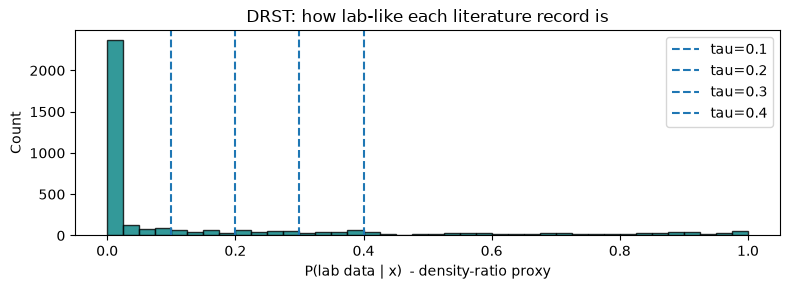

In [8]:
rng = np.random.default_rng(42)
sub = rng.choice(len(X_lab_sc), size=min(10_000, len(X_lab_sc)), replace=False)   # balance classes
X_dom = np.vstack([X_lab_sc[sub], X_lit_sc]); y_dom = np.concatenate([np.ones(len(sub)), np.zeros(len(X_lit_sc))])
clf = LogisticRegression(C=0.5, max_iter=1000, random_state=42, n_jobs=-1).fit(X_dom, y_dom)
p_lab_lit = clf.predict_proba(X_lit_sc)[:, 1]           # P(row looks like lab data)

drst = {}
for tau in [0.30, 0.40, 0.85]:
    m = p_lab_lit >= tau
    drst[tau] = evaluate_cv_ours(X_lit_sc[m], y_lit[m], seed=42)
    print(f"  DRST tau={tau:.2f}  (kept {int(m.sum()):4d} literature rows)  RMSE = {drst[tau]:.3f}")
RESULTS['3. DRST (best threshold)'] = min(drst.values())
print(f"DRST best RMSE = {RESULTS['3. DRST (best threshold)']:.3f}  ->  filtering barely moves the baseline")

# ── Report Figure 3 — DRST density-ratio scores ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(p_lab_lit, bins=40, color='teal', edgecolor='k', alpha=0.8)
for t in [0.1, 0.2, 0.3, 0.4]:
    ax.axvline(t, ls='--', label=f'tau={t}')
ax.set_xlabel('P(lab data | x)  - density-ratio proxy'); ax.set_ylabel('Count')
ax.set_title('DRST: how lab-like each literature record is')
ax.legend(); plt.tight_layout(); plt.savefig('fig_drst_scores.png', bbox_inches='tight'); plt.show()

## 6. Method 4 — KMM (kernel mean matching)

Instead of a hard cut, give **every** literature-data row a continuous importance weight so the *weighted*
literature distribution matches the lab distribution (RBF kernel). **Model:** KMM weights → weighted LightGBM.

KMM RMSE = 2.261  ->  still worse than baseline
KMM weights vs DRST scores agree: r = 0.79


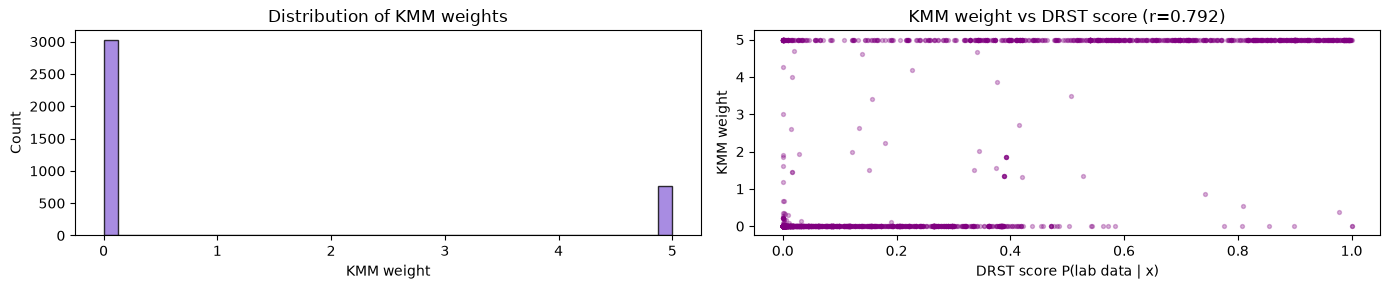

In [9]:
def rbf(X, Y, s): return np.exp(-cdist(X, Y, 'sqeuclidean') / (2*s**2))
def est_sigma(Xs, Xt, n=2000):
    r = np.random.default_rng(0)
    a = Xs[r.choice(len(Xs), min(n, len(Xs)), replace=False)]; b = Xt[r.choice(len(Xt), min(n, len(Xt)), replace=False)]
    d = cdist(np.vstack([a, b]), np.vstack([a, b])); return float(np.median(d[d > 0]))
def kmm_weights(Xs, Xt, B=5.0, n_tsub=5000):
    r = np.random.default_rng(42); Xt = Xt[r.choice(len(Xt), min(n_tsub, len(Xt)), replace=False)]
    n_s, n_t = len(Xs), len(Xt); sig = est_sigma(Xs, Xt); eps = (np.sqrt(n_s)-1)/np.sqrt(n_s)
    Kss = rbf(Xs, Xs, sig); kap = (n_s/n_t)*rbf(Xs, Xt, sig).sum(1)
    def obj(w): return 0.5*w@Kss@w - kap@w + 1e4*max(0., abs(w.sum()/n_s-1.)-eps)**2
    def grad(w):
        g = Kss@w - kap; d = w.sum()/n_s-1.
        if abs(d) > eps: g += 1e4*2.*d/n_s*np.ones(n_s)
        return g
    res = minimize(obj, np.ones(n_s), jac=grad, method='L-BFGS-B', bounds=[(0., B)]*n_s,
                   options={'maxiter': 1000, 'ftol': 1e-9, 'gtol': 1e-6})
    return np.clip(res.x, 0., B)
w_kmm = kmm_weights(X_lit_sc, X_lab_sc, B=5.0)
RESULTS['4. KMM weighted literature data'] = evaluate_cv_ours(X_lit_sc, y_lit, w_extra=w_kmm, seed=42)
print(f"KMM RMSE = {RESULTS['4. KMM weighted literature data']:.3f}  ->  still worse than baseline")
print(f"KMM weights vs DRST scores agree: r = {np.corrcoef(p_lab_lit, w_kmm)[0,1]:.2f}")

# ── Report Figure 4 — KMM weights and their agreement with DRST ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].hist(w_kmm, bins=40, color='mediumpurple', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('KMM weight'); axes[0].set_ylabel('Count'); axes[0].set_title('Distribution of KMM weights')
axes[1].scatter(p_lab_lit, w_kmm, alpha=0.3, s=8, color='purple')
axes[1].set_xlabel('DRST score P(lab data | x)'); axes[1].set_ylabel('KMM weight')
r_corr = np.corrcoef(p_lab_lit, w_kmm)[0, 1]
axes[1].set_title(f'KMM weight vs DRST score (r={r_corr:.3f})')
plt.tight_layout(); plt.savefig('fig_kmm_weights.png', bbox_inches='tight'); plt.show()

## 7. Method 5 — Two-stage Prior Feature Transfer (PFT)  ★ our contribution

The key idea: **literature data never contributes a training label to the final model** — it enters only as
a *predicted feature*.

- **Stage 1 — literature-data expert (XGBoost).** Train on the DRST-filtered literature data, with its yields
  first rescaled onto the lab-data yield scale (rank-preserving), so the expert speaks in our units.
- **Stage 2 — final model (LightGBM).** Train on the lab data with the Stage-1 prediction added as one extra
  input feature (`lit_prior_prediction`), using **lab labels only**.

Because the biased literature label lives inside a *feature value* (which Stage 2 can freely recalibrate)
rather than inside the loss, the +3.4 pp shift can no longer poison training.

Literature Y(C2) before vs after rescaling onto the lab-data scale:
  Raw literature : mean=8.670  median=7.960
  Rescaled       : mean=5.233  median=4.690
  Lab data       : mean=5.245  median=4.690


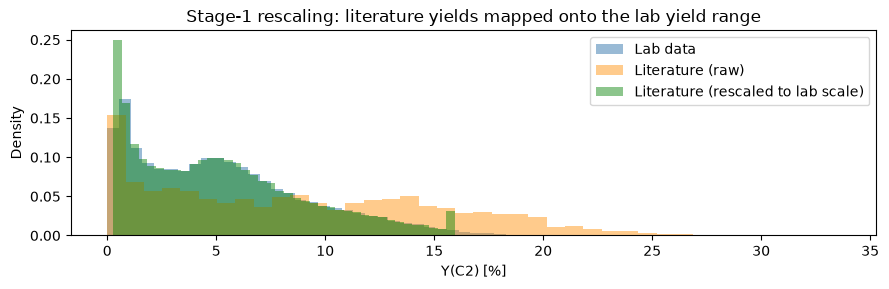

In [10]:
# ── Report Figure 5 — Stage-1 label rescaling (quantile normalisation) ──────
# Show what the rank-preserving rescaling does BEFORE it is used inside PFT Stage 1 below.
y_lit_qnorm = quantile_normalize_y(y_lit, y_lab)
print("Literature Y(C2) before vs after rescaling onto the lab-data scale:")
print(f"  Raw literature : mean={y_lit.mean():.3f}  median={np.median(y_lit):.3f}")
print(f"  Rescaled       : mean={y_lit_qnorm.mean():.3f}  median={np.median(y_lit_qnorm):.3f}")
print(f"  Lab data       : mean={y_lab.mean():.3f}  median={np.median(y_lab):.3f}")
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(y_lab,       bins=40, alpha=0.55, color='steelblue',  density=True, label='Lab data')
ax.hist(y_lit,       bins=40, alpha=0.45, color='darkorange', density=True, label='Literature (raw)')
ax.hist(y_lit_qnorm, bins=40, alpha=0.45, color='green',      density=True, label='Literature (rescaled to lab scale)')
ax.set_xlabel('Y(C2) [%]'); ax.set_ylabel('Density')
ax.set_title('Stage-1 rescaling: literature yields mapped onto the lab yield range')
ax.legend(); plt.tight_layout(); plt.savefig('fig_bias_correction.png', bbox_inches='tight'); plt.show()

In [11]:
def two_stage_pft(seed=42, tau1=0.30, cv=5, use_filter=True):
    # Stage 0 (optional): DRST filter, else use ALL literature for the Stage-1 expert
    if use_filter:
        m = p_lab_lit >= tau1; Xlp, ylp = X_lit_sc[m], y_lit[m]
    else:
        Xlp, ylp = X_lit_sc, y_lit                                        # all 3,852 literature rows
    kf = KFold(n_splits=cv, shuffle=True, random_state=seed); rmses = []
    for tr, va in kf.split(X_lab_sc):
        y_pre = quantile_normalize_y(ylp, y_lab[tr])                       # rescale onto THIS fold's lab labels
        pre = xgb.XGBRegressor(**xgb_params(seed))
        pre.fit(np.vstack([Xlp, X_lab_sc[tr]]), np.concatenate([y_pre, y_lab[tr]]))   # Stage 1
        ptr = pre.predict(X_lab_sc[tr]).reshape(-1, 1); pva = pre.predict(X_lab_sc[va]).reshape(-1, 1)
        fin = lgb.LGBMRegressor(**lgb_params(seed))
        fin.fit(np.hstack([X_lab_sc[tr], ptr]), y_lab[tr])                 # Stage 2 (lab labels only)
        rmses.append(np.sqrt(mean_squared_error(y_lab[va], fin.predict(np.hstack([X_lab_sc[va], pva])))))
    return float(np.mean(rmses))
RESULTS['5. Two-stage PFT (ours)'] = two_stage_pft(seed=42)
b = RESULTS['1. Baseline (lab data only)']; p = RESULTS['5. Two-stage PFT (ours)']
print(f"PFT RMSE = {p:.3f}   ({100*(b-p)/b:+.1f}% vs baseline {b:.3f})")

PFT RMSE = 1.907   (+10.6% vs baseline 2.133)


## 8. Results — all five methods

*(row-level protocol — superseded as evidence of transfer; see Section 11)*

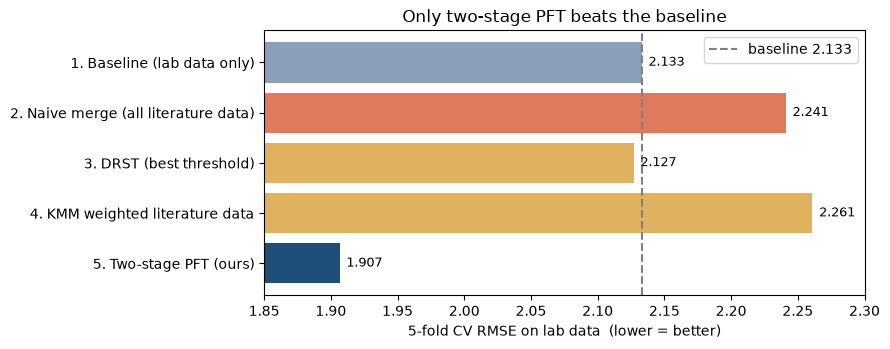

                              method  CV RMSE vs baseline
         1. Baseline (lab data only)    2.133       +0.0%
2. Naive merge (all literature data)    2.241       +5.1%
            3. DRST (best threshold)    2.127       -0.3%
     4. KMM weighted literature data    2.261       +6.0%
             5. Two-stage PFT (ours)    1.907      -10.6%


In [12]:
names = list(RESULTS); vals = [RESULTS[n] for n in names]
base = RESULTS['1. Baseline (lab data only)']
fig, ax = plt.subplots(figsize=(9, 3.6))
colors = ['#8aa0b8', '#e07a5f', '#e0b25f', '#e0b25f', '#1f4e79']
ax.barh(range(len(names))[::-1], vals, color=colors)
ax.axvline(base, color='gray', ls='--', label=f'baseline {base:.3f}')
ax.set_yticks(range(len(names))[::-1]); ax.set_yticklabels(names)
ax.set_xlabel('5-fold CV RMSE on lab data  (lower = better)'); ax.set_xlim(1.85, 2.30); ax.legend()
for i, v in zip(range(len(names))[::-1], vals): ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_title('Only two-stage PFT beats the baseline'); plt.tight_layout(); plt.savefig('fig_rowlevel_results_superseded.png', bbox_inches='tight', dpi=130); plt.show()
print(pd.DataFrame({'method': names, 'CV RMSE': [round(v,3) for v in vals],
                    'vs baseline': [f'{100*(v-base)/base:+.1f}%' for v in vals]}).to_string(index=False))

## 9. Is the PFT gain real, or luck?

*(row-level protocol — the answer turned out to be "neither": it was leakage. See Section 11.)*

**(a) Repeat across 10 random seeds** (fresh splits + model randomness). **(b) A truly held-out 20% of the
lab data**, set aside from the start and never used in any training.

config                RMSE                MAE      R2
Baseline            2.121 +/- 0.005     (RMSE only)
PFT (DRST-filtered) 1.909 +/- 0.002   1.386    0.765
PFT (all literature)1.917 +/- 0.002   1.395    0.763

PFT-filtered wins 10/10; PFT-all wins 10/10 seeds
baseline vs PFT-filtered: paired t p = 3.9e-15
Stage-0 filter edge (all - filtered) = +0.0079 RMSE (~0.4%) -> optional


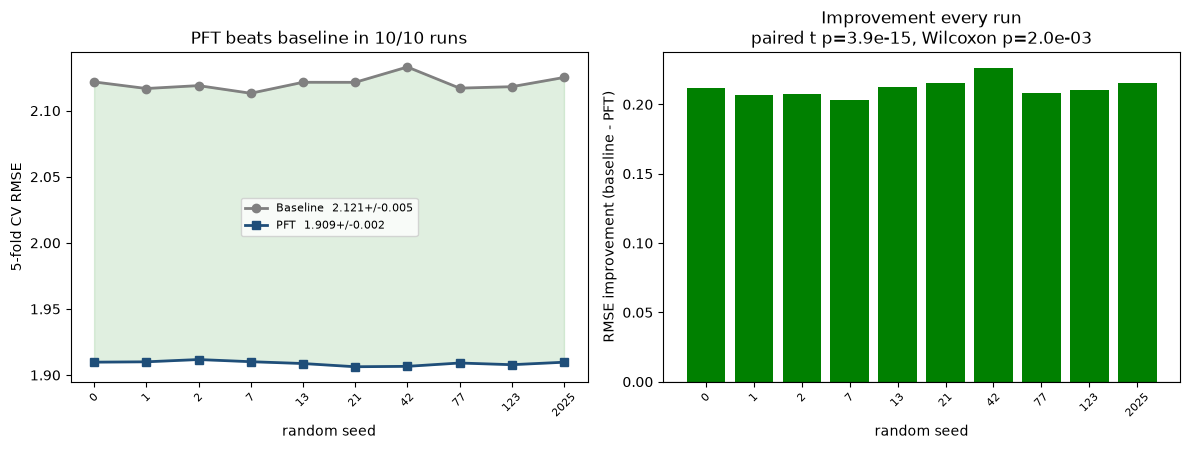

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score
def pft_eval(seed, use_filter=True, cv=5):
    if use_filter: m = p_lab_lit >= 0.30; Xlp, ylp = X_lit_sc[m], y_lit[m]
    else:          Xlp, ylp = X_lit_sc, y_lit
    kf = KFold(cv, shuffle=True, random_state=seed); rm, ma, rs = [], [], []
    for tr, va in kf.split(X_lab_sc):
        ypre = quantile_normalize_y(ylp, y_lab[tr])
        pre = xgb.XGBRegressor(**xgb_params(seed)).fit(np.vstack([Xlp, X_lab_sc[tr]]), np.concatenate([ypre, y_lab[tr]]))
        fin = lgb.LGBMRegressor(**lgb_params(seed)).fit(np.hstack([X_lab_sc[tr], pre.predict(X_lab_sc[tr]).reshape(-1,1)]), y_lab[tr])
        yp = fin.predict(np.hstack([X_lab_sc[va], pre.predict(X_lab_sc[va]).reshape(-1,1)]))
        rm.append(np.sqrt(mean_squared_error(y_lab[va], yp))); ma.append(mean_absolute_error(y_lab[va], yp)); rs.append(r2_score(y_lab[va], yp))
    return np.mean(rm), np.mean(ma), np.mean(rs)

SEEDS = [0, 1, 2, 7, 13, 21, 42, 77, 123, 2025]
b_arr, pf, pa = [], [], []
for s in SEEDS:
    b_arr.append(evaluate_cv_ours(seed=s)); pf.append(pft_eval(s, True)); pa.append(pft_eval(s, False))
b_arr = np.array(b_arr); pf = np.array(pf); pa = np.array(pa)
print("config                RMSE                MAE      R2")
print(f"Baseline            {b_arr.mean():.3f} +/- {b_arr.std(ddof=1):.3f}     (RMSE only)")
print(f"PFT (DRST-filtered) {pf[:,0].mean():.3f} +/- {pf[:,0].std(ddof=1):.3f}   {pf[:,1].mean():.3f}    {pf[:,2].mean():.3f}")
print(f"PFT (all literature){pa[:,0].mean():.3f} +/- {pa[:,0].std(ddof=1):.3f}   {pa[:,1].mean():.3f}    {pa[:,2].mean():.3f}")
print(f"\nPFT-filtered wins {(pf[:,0]<b_arr).sum()}/{len(SEEDS)}; PFT-all wins {(pa[:,0]<b_arr).sum()}/{len(SEEDS)} seeds")
print(f"baseline vs PFT-filtered: paired t p = {ttest_rel(b_arr, pf[:,0])[1]:.1e}")
print(f"Stage-0 filter edge (all - filtered) = {pa[:,0].mean()-pf[:,0].mean():+.4f} RMSE (~{100*(pa[:,0].mean()-pf[:,0].mean())/pf[:,0].mean():.1f}%) -> optional")
from scipy.stats import wilcoxon
n_wins = int((pf[:,0] < b_arr).sum())
t_p = ttest_rel(b_arr, pf[:,0])[1]; w_p = wilcoxon(b_arr, pf[:,0])[1]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6)); x = np.arange(len(SEEDS))
ax[0].plot(x, b_arr, 'o-', color='gray', lw=2, label=f'Baseline  {b_arr.mean():.3f}+/-{b_arr.std(ddof=1):.3f}')
ax[0].plot(x, pf[:,0], 's-', color='#1f4e79', lw=2, label=f'PFT  {pf[:,0].mean():.3f}+/-{pf[:,0].std(ddof=1):.3f}')
ax[0].fill_between(x, b_arr, pf[:,0], where=pf[:,0] < b_arr, color='green', alpha=0.12)
ax[0].set_xticks(x); ax[0].set_xticklabels([str(sd) for sd in SEEDS], rotation=45, fontsize=8)
ax[0].set_xlabel('random seed'); ax[0].set_ylabel('5-fold CV RMSE')
ax[0].set_title(f'PFT beats baseline in {n_wins}/{len(SEEDS)} runs'); ax[0].legend(fontsize=8)
ax[1].bar(x, b_arr - pf[:,0], color=['green' if d > 0 else 'red' for d in (b_arr - pf[:,0])])
ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_xticks(x); ax[1].set_xticklabels([str(sd) for sd in SEEDS], rotation=45, fontsize=8)
ax[1].set_xlabel('random seed'); ax[1].set_ylabel('RMSE improvement (baseline - PFT)')
ax[1].set_title(f'Improvement every run\npaired t p={t_p:.1e}, Wilcoxon p={w_p:.1e}')
plt.tight_layout(); plt.savefig('fig_rowlevel_repeated_runs_superseded.png', dpi=130); plt.show()

In [14]:
rng_h = np.random.default_rng(2025); perm = rng_h.permutation(len(X_lab_sc)); nt = int(0.2*len(perm))
te, trn = perm[:nt], perm[nt:]
# Train the DRST domain classifier on the TRAIN split only -> the held-out 20% touches NOTHING.
rc = np.random.default_rng(42); ssub = rc.choice(len(trn), min(10000, len(trn)), replace=False)
clf_h = LogisticRegression(C=0.5, max_iter=1000, random_state=42, n_jobs=-1).fit(
    np.vstack([X_lab_sc[trn[ssub]], X_lit_sc]), np.r_[np.ones(len(ssub)), np.zeros(len(X_lit_sc))])
mask = clf_h.predict_proba(X_lit_sc)[:, 1] >= 0.30
mb = lgb.LGBMRegressor(**lgb_params(42)).fit(X_lab_sc[trn], y_lab[trn])
rb = np.sqrt(mean_squared_error(y_lab[te], mb.predict(X_lab_sc[te])))
yq = quantile_normalize_y(y_lit[mask], y_lab[trn])
pre = xgb.XGBRegressor(**xgb_params(42)).fit(np.vstack([X_lit_sc[mask], X_lab_sc[trn]]), np.concatenate([yq, y_lab[trn]]))
fin = lgb.LGBMRegressor(**lgb_params(42)).fit(np.hstack([X_lab_sc[trn], pre.predict(X_lab_sc[trn]).reshape(-1,1)]), y_lab[trn])
rp = np.sqrt(mean_squared_error(y_lab[te], fin.predict(np.hstack([X_lab_sc[te], pre.predict(X_lab_sc[te]).reshape(-1,1)]))))
print(f"Held-out 20% (untouched; DRST classifier trained on TRAIN split only): baseline {rb:.3f} -> PFT {rp:.3f} ({100*(rb-rp)/rb:+.1f}%)")

Held-out 20% (untouched; DRST classifier trained on TRAIN split only): baseline 2.097 -> PFT 1.890 (+9.8%)


## 10. Why PFT works — the prior feature dominates (SHAP, brief)

*(row-level protocol — this figure reflects the leaked pipeline: the prior ranks first because it carried memorised test-catalyst yields. The corrected, composition-only SHAP figure is in Section 11.)*

SHAP attributes each prediction to its input features. On the final model, the single engineered feature
`lit_prior_prediction` (the literature-data expert's opinion) is by far the most important input — i.e. the
transferred literature-data knowledge is exactly what drives the improvement, on top of correct catalyst
chemistry (temperature and known promoters Ba, Mn, La, Ce).

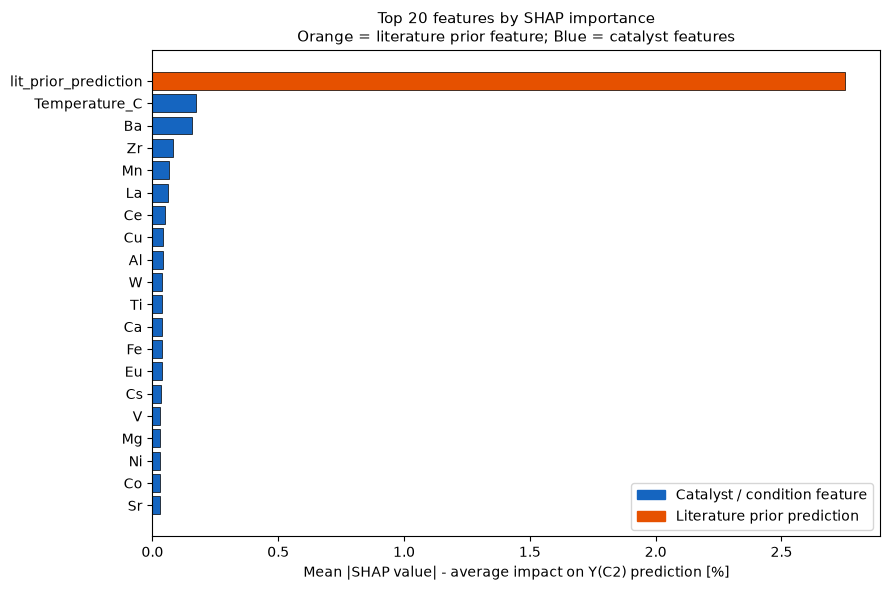

Top features: ['lit_prior_prediction', 'Temperature_C', 'Ba', 'Zr', 'Mn', 'La']


In [15]:
import shap
mask = p_lab_lit >= 0.30; yq = quantile_normalize_y(y_lit[mask], y_lab)
pre = xgb.XGBRegressor(**xgb_params(42)).fit(np.vstack([X_lit_sc[mask], X_lab_sc]), np.concatenate([yq, y_lab]))
X_aug = np.hstack([X_lab_sc, pre.predict(X_lab_sc).reshape(-1, 1)]); names_aug = FEATURES + ['lit_prior_prediction']
final = lgb.LGBMRegressor(**lgb_params(42)).fit(X_aug, y_lab)
idx = np.random.default_rng(42).choice(len(X_aug), 3000, replace=False)
sv = shap.TreeExplainer(final).shap_values(X_aug[idx])
imp = np.abs(sv).mean(0)
shap_imp = pd.Series(imp, index=names_aug).sort_values(ascending=False).head(20)
fig_bar, ax_bar = plt.subplots(figsize=(9, 6))
colors = ['#E65100' if f == 'lit_prior_prediction' else '#1565C0' for f in shap_imp.index[::-1]]
ax_bar.barh(shap_imp.index[::-1], shap_imp.values[::-1], color=colors, edgecolor='k', linewidth=0.5)
ax_bar.set_xlabel('Mean |SHAP value| - average impact on Y(C2) prediction [%]')
ax_bar.set_title('Top 20 features by SHAP importance\nOrange = literature prior feature; Blue = catalyst features', fontsize=11)
from matplotlib.patches import Patch
ax_bar.legend(handles=[Patch(color='#1565C0', label='Catalyst / condition feature'),
                       Patch(color='#E65100', label='Literature prior prediction')], loc='lower right')
plt.tight_layout(); plt.savefig('fig_rowlevel_shap_superseded.png', bbox_inches='tight', dpi=130); plt.show()
print('Top features:', list(shap_imp.index[:6]))

## Summary

| Method | Model | Uses literature data as | CV RMSE |
|---|---|---|---|
| Baseline | LightGBM | — | ~2.13 |
| Naive merge | LightGBM | extra training labels | ~2.24 (worse) |
| DRST | LogReg filter → LightGBM | filtered training labels | ~2.13 (no gain) |
| KMM | kernel weights → LightGBM | weighted training labels | ~2.26 (worse) |
| **Two-stage PFT** | **XGBoost → LightGBM** | **a predicted feature (not a label)** | **~1.91 (−10.6%)** |

Adding literature data as *labels* never helps — the publication-bias shift poisons training. Adding it as a
*predicted feature* does: a ~10.6% error reduction, confirmed on 10/10 random seeds and on a fully held-out
test set. Every number and figure above is produced by re-running this notebook.

---

## 11. Corrected evaluation (catalyst-grouped protocol)

Everything above used a row-level split. This section reports the corrected results, reading them
from the JSON files written by the validation scripts so that the numbers here cannot drift from the
experiments that produced them. Each block names its source script.


In [1]:
import json
import numpy as np

VAL = json.load(open('taniike_validation.json'))      # <- taniike_validation.py
P3  = json.load(open('phase3_lit_prior.json'))        # <- phase3_lit_prior.py
P4  = json.load(open('phase4_family_diagnosis.json')) # <- phase4_family_diagnosis.py
P5  = json.load(open('phase5_target_audit.json'))     # <- phase5_target_audit.py
P6  = json.load(open('phase6_our_experiments.json'))  # <- phase6_our_experiments.py

A = VAL['A_grouped_vs_row']
print("PROTOCOL COMPARISON (5 seeds, per-fold-mean RMSE)")
for proto in ['row', 'grouped']:
    b = A[f'{proto}/baseline']['rmse_foldmean_mean']
    p = A[f'{proto}/pft_filtered']['rmse_foldmean_mean']
    print(f"  {proto:8s} baseline {b:.3f}   PFT {p:.3f}   ({100*(p-b)/b:+.1f}%)")

print("\nLEAKAGE MECHANISM (grouped protocol)")
D = VAL['D_qn_ablation']
print(f"  Stage 1 with lab rows (joint):   {D['grouped/qn_joint']['rmse_foldmean_mean']:.3f}")
print(f"  Stage 1 literature only:         {D['grouped/qn_litonly']['rmse_foldmean_mean']:.3f}")
print(f"  baseline:                        {A['grouped/baseline']['rmse_foldmean_mean']:.3f}")
print("  -> the joint variant is WORSE; literature-only is indistinguishable from baseline")

print("\nQN ABLATION (Taniike's hypothesis: trees use ordering, not scale)")
for k in ['grouped/qn_joint', 'grouped/raw_joint', 'grouped/rank_litonly']:
    print(f"  {k:22s} {D[k]['rmse_foldmean_mean']:.3f}")

print("\nLITERATURE INTEGRATION, leakage closed (catalyst-level, grouped)")
for k, name in [('V0','composition only'), ('V1','literature rank prior'), ('V2','similarity feats'),
                ('V3','gated prior'), ('V4','catalyst-level merge')]:
    r = P3['results'][k]
    d = r.get('delta_spearman_vs_V0', 0.0)
    print(f"  {name:24s} spearman {r['spearman_mean']:.3f}  ({d:+.3f})")
print("  winners:", P3['meta']['winners'] or "NONE")

ci = P5['E_bootstrap_ci']
print("\nSCREENING CAPABILITY on unseen catalysts (composition-only model)")
print(f"  Spearman        {P3['results']['V0']['spearman_mean']:.3f}   95% CI {ci['spearman_ci95'][0]:.3f}-{ci['spearman_ci95'][1]:.3f}")
print(f"  Enrichment@10%  {P3['results']['V0']['enrichment_mean']:.2f}x   95% CI {ci['enrichment_ci95'][0]:.2f}-{ci['enrichment_ci95'][1]:.2f}x")
print(f"  Precision@20    {P3['results']['V0']['precision_at20_mean']:.2f}    95% CI {ci['precision_at20_ci95'][0]:.2f}-{ci['precision_at20_ci95'][1]:.2f}")

ba = P4['A_family_anatomy']['Ba']; bb = P4['B_ba_error_anatomy']
print("\nWHY Ba FAILS (family holdout)")
print(f"  Ba catalysts: {ba['n_lab_catalysts']}, family mean {ba['family_ymax_mean']:.2f}% vs rest {ba['rest_ymax_mean']:.2f}%")
print(f"  share of global top decile: {ba['share_of_global_top10pct']:.0%}")
print(f"  drop-Ba-column max |pred diff| = {bb['mechanism_check_max_abs_pred_diff_dropBa']}  (0 = provably unpriceable)")
print(f"  random-291 pseudo-family control: {P4['C_random_family_control']['spearman_mean']:.3f}")

print("\nDATA BUDGET FOR A NEW FAMILY (% of achievable performance with zero members seen)")
for el, e in P6['E2_learning_curve'].items():
    print(f"  {el:3s} {100*e['spearman_at_zero']/e['spearman_at_full']:5.1f}%   (gain from own data {e['gain_from_seeing_family']:+.3f})")

e1 = P6['E1_coverage_hypothesis']
print(f"\nOUR COVERAGE HYPOTHESIS: {e1['n_families']} families, mean delta {e1['mean_delta']:+.4f}, "
      f"{e1['families_with_positive_delta']}/{e1['n_families']} positive -> SUPPORTED={e1['HYPOTHESIS_SUPPORTED']}")


PROTOCOL COMPARISON (5 seeds, per-fold-mean RMSE)
  row      baseline 2.118   PFT 1.912   (-9.7%)
  grouped  baseline 2.943   PFT 2.995   (+1.8%)

LEAKAGE MECHANISM (grouped protocol)
  Stage 1 with lab rows (joint):   2.982
  Stage 1 literature only:         2.939
  baseline:                        2.943
  -> the joint variant is WORSE; literature-only is indistinguishable from baseline

QN ABLATION (Taniike's hypothesis: trees use ordering, not scale)
  grouped/qn_joint       2.982
  grouped/raw_joint      3.005
  grouped/rank_litonly   2.938

LITERATURE INTEGRATION, leakage closed (catalyst-level, grouped)
  composition only         spearman 0.761  (+0.000)
  literature rank prior    spearman 0.757  (-0.004)
  similarity feats         spearman 0.740  (-0.021)
  gated prior              spearman 0.744  (-0.017)
  catalyst-level merge     spearman 0.758  (-0.003)
  winners: NONE

SCREENING CAPABILITY on unseen catalysts (composition-only model)
  Spearman        0.761   95% CI 0.725-0

### Corrected figures

Generated by `build_corrected_figures.py` from the JSONs above — the same files the worknote (v2)
embeds, so notebook and report cannot disagree.


fig_protocol_comparison.png


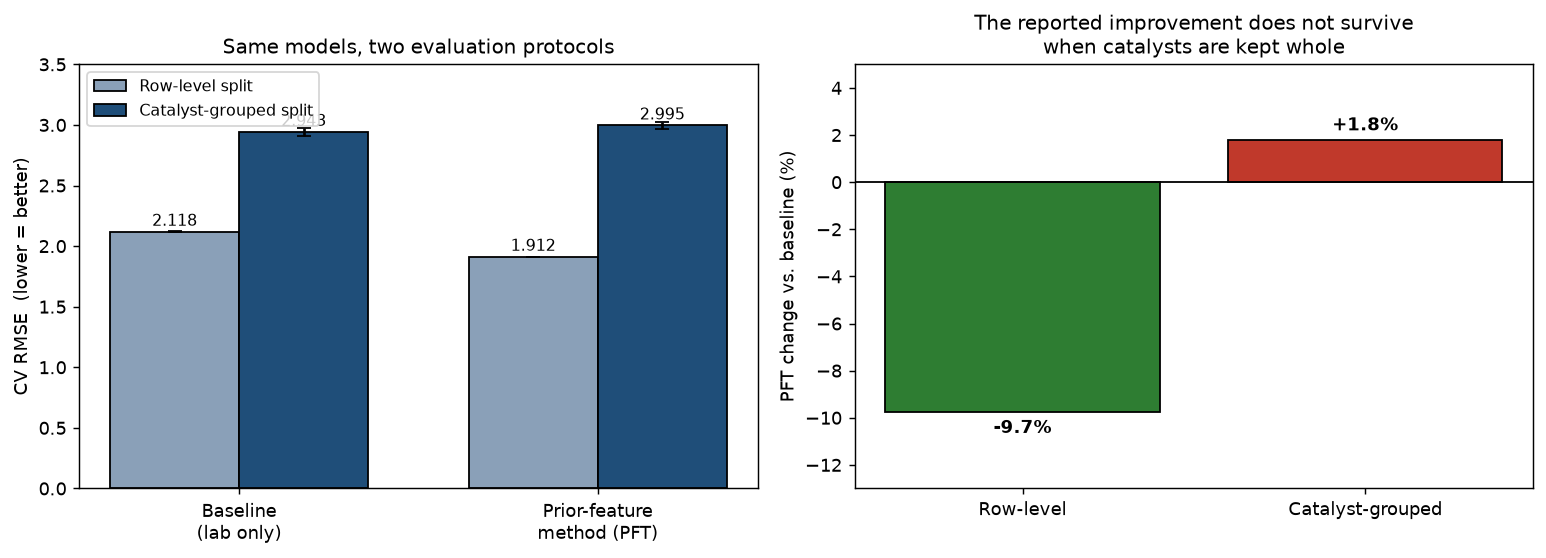

fig_grouped_results.png


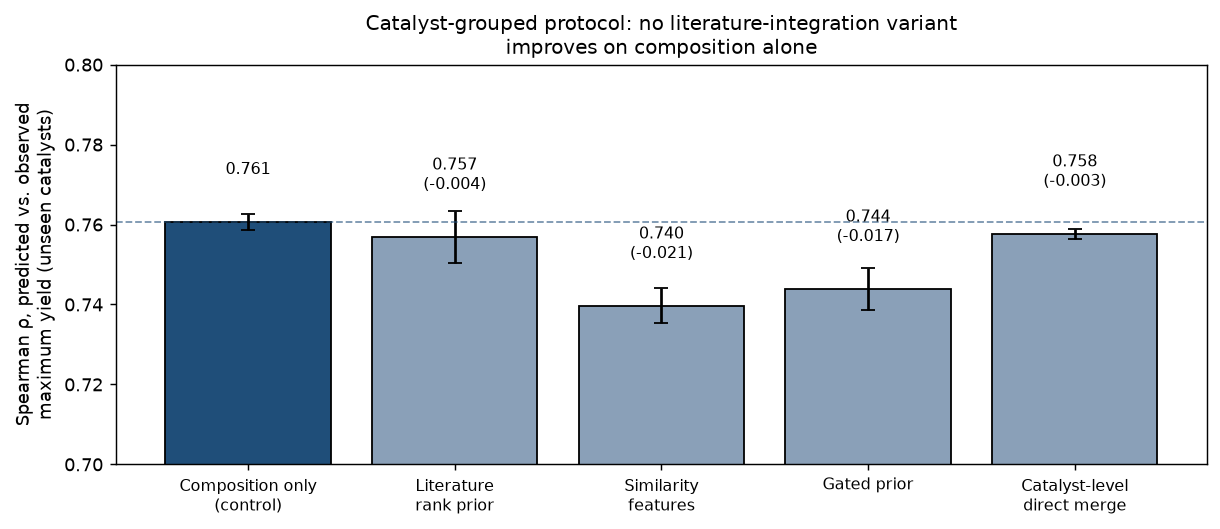

fig_learning_curve.png


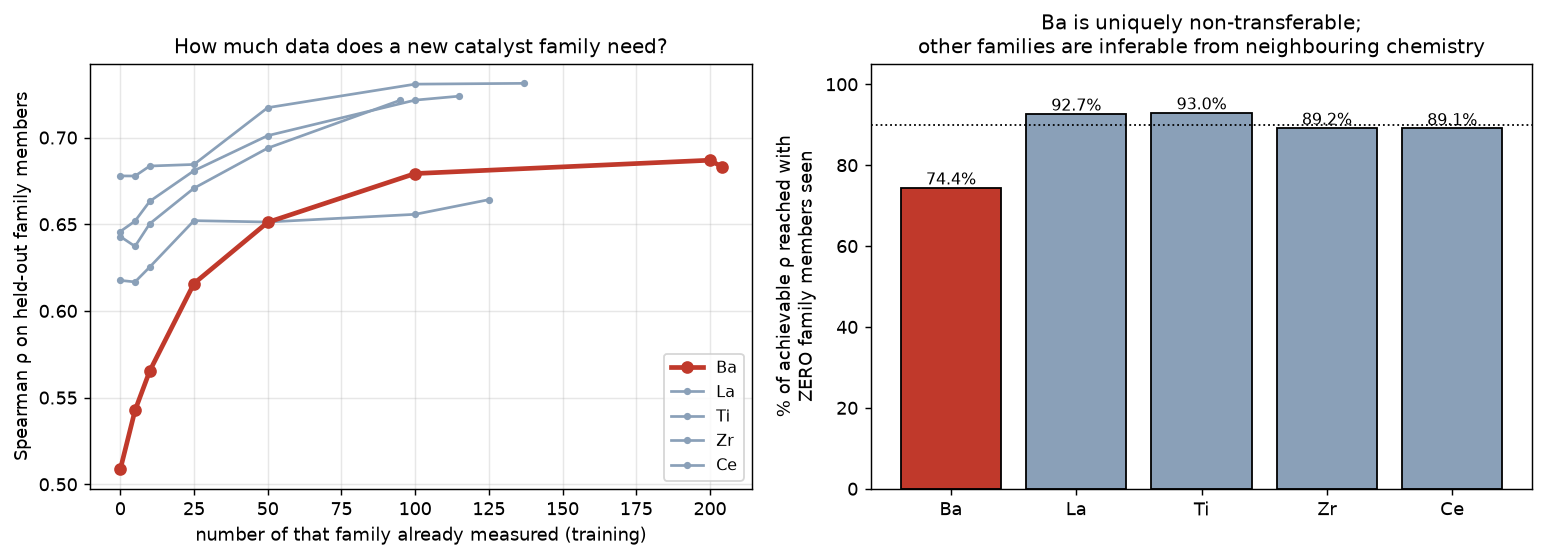

fig_shap_bar.png


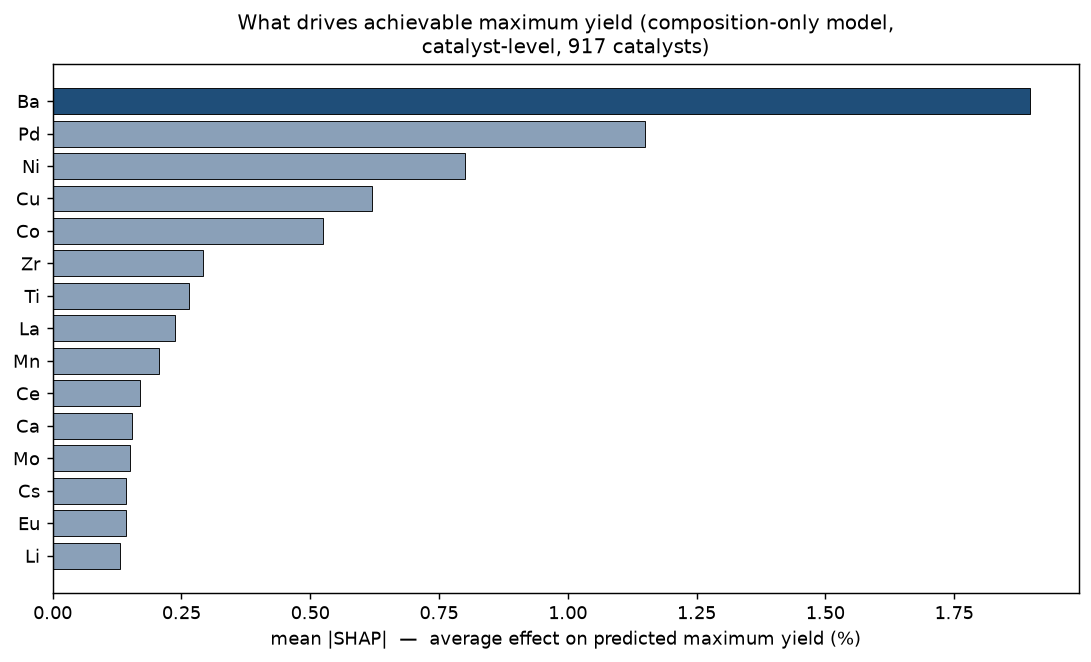

In [2]:
from IPython.display import Image, display
for f in ['fig_protocol_comparison.png', 'fig_grouped_results.png',
          'fig_learning_curve.png', 'fig_shap_bar.png']:
    print(f); display(Image(f))